In [15]:

import sys
import os
sys.path.append(os.path.abspath("../../"))

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import Normalizer
from utility.preprocess import tokenizer, has_thai
from utility.lexicon import LexiconTransformer
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

import json
import pandas as pd
import pickle



In [16]:
with open("../../dataset/train_sentiment.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

In [ ]:
text = df['text']
sentiment = df['sentiment']

In [18]:
text_train, text_test, sentiment_train, sentiment_test = train_test_split(
    text, sentiment, test_size=0.1, random_state=42
)

In [19]:
base_models = [
    ("svm", LinearSVC(class_weight="balanced", random_state=42)),
    ("nb", MultinomialNB()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ("sgd", SGDClassifier(loss="log_loss", class_weight="balanced", random_state=42)),
    
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [21]:
word_vectorizer = TfidfVectorizer(
    tokenizer=tokenizer,
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_df=0.9,
    min_df=1
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb', 
    ngram_range=(1, 3), 
    sublinear_tf=True,
    max_df=0.9,
    min_df=3
)

combined_features = FeatureUnion([
    ("word_tfidf", word_vectorizer),
    ("char_tfidf", char_vectorizer),
    ("lexicon", LexiconTransformer())
], transformer_weights={
    "word_tfidf": 1.0,
    "char_tfidf": 0.5,
    "lexicon": 1.0
})

In [22]:
pipeline = Pipeline([
    ('features', combined_features),
    ('norm', Normalizer()),
    ('classifier', stack_model)
])

pipeline.fit(text_train, sentiment_train)

c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('norm', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('word_tfidf', ...), ('char_tfidf', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.","{'char_tfidf': 0.5, 'lexicon': 1.0, 'word_tfidf': 1.0}"
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


In [23]:
y_pred = pipeline.predict(text_test)

print("Accuracy:", accuracy_score(sentiment_test, y_pred))
print(classification_report(sentiment_test, y_pred))

Accuracy: 0.8088888888888889
              precision    recall  f1-score   support

    negative       0.85      0.84      0.84       294
     neutral       0.77      0.75      0.76       300
    positive       0.81      0.83      0.82       306

    accuracy                           0.81       900
   macro avg       0.81      0.81      0.81       900
weighted avg       0.81      0.81      0.81       900



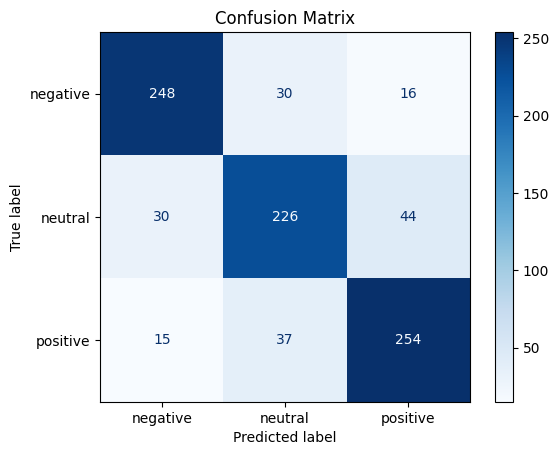

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    sentiment_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

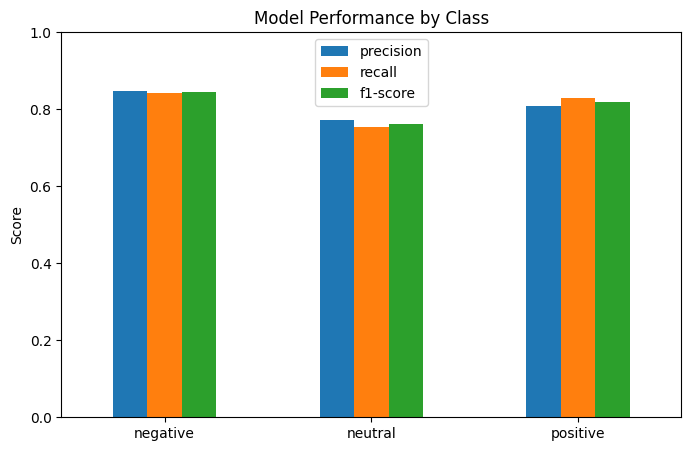

In [25]:
report = classification_report(sentiment_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

df = df.iloc[:3]

df[["precision","recall","f1-score"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Performance by Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()

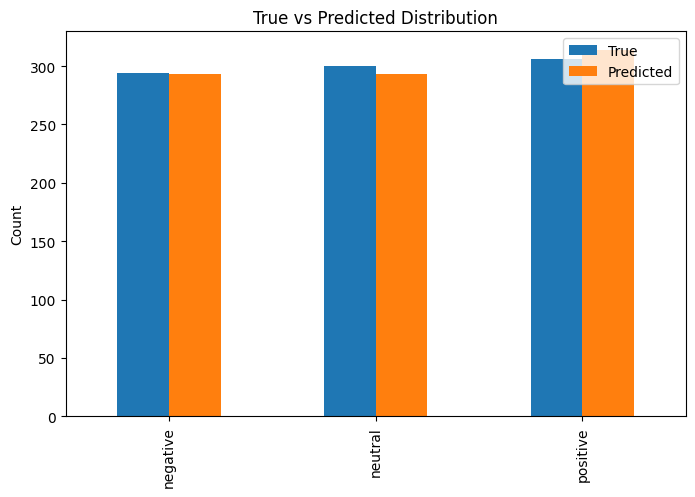

In [26]:
true_counts = pd.Series(sentiment_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()

df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
})

df.plot(kind="bar", figsize=(8,5))
plt.title("True vs Predicted Distribution")
plt.ylabel("Count")
plt.show()

In [27]:
for text, true, pred in zip(text_test, sentiment_test, y_pred):
    if true != pred:
        print("TEXT:", text)
        print("TRUE:", true, "PRED:", pred)
        print()

TEXT: #6มีนาคม #เขตบางนา #ก้าวสู่ปีที่28 🎉  สำนักงานเขตบางนา จัดพิธีทำบุญเนื่องในโอกาสวันสถาปนาสำนักงานเขตบางนา ครบรอบปีที่ 27 ก้าวสู่ปีที่ 28 โดยในเวลา 08.19 น. นางประภัสสร จำนงบุตร ผู้อำนวยการเขตบางนา นำคณะผู้บริหารเขต คณะผู้บริหารสถานศึกษาในสังกัดสำนักงานเขต สัสดีเขตบางนา ข้าราชการและบุคลากรสำนักงานเขต ร่วมสักการะพระพุทธพิชิตมาร ศาลพระภูมิเจ้าที่ และศาลตายาย สิ่งศักดิ์สิทธิ์ประจำเขตบางนา บริเวณหน้าอาคารสำนักงานเขตบางนา  เพื่อความร่มเย็น เป็นสุข และเป็นสิริมงคล  🤍🙏 #วันสถาปนาสำนักงานเขตบางนา #กรุงเทพมหานคร #กทม #บางนา #สำนักงานเขตบางนา
TRUE: positive PRED: neutral

TEXT: ไฟไหม้ มีภัย โทร.199 เรียกนักดับเพลิงและกู้ภัย สปภ.กทม.  นักดับเพลิงและกู้ภัยสุทธิสาร กปก.1  1. รับแจ้งจับงูเขียวพระอินทร์ ไม่พบตัวงูดังกล่าว ประชาสัมพันธ์เรียบร้อย ที่เกิดเหตุแฟลต กทม. แฟลต 9 ชั้น 3 ห้อง 500 แขวงรัชดาภิเษก เขตดินแดง กทม. 2....
TRUE: negative PRED: neutral

TEXT: วันพุธที่ 9 ตุลาคม 2567 สำนักงานสัตวแพทย์สาธารณสุข ร่วมกับ ฝ่ายสิ่งแวดล้อมและสุขาภิบาล สำนักงานเขตหลักสี่ และสมาชิกสภากรุงเทพมหานคร เขตหลัก

In [ ]:

# with open("../../models/weights/stack_model.pkl", "wb") as f:
#     pickle.dump(pipeline, f)

Training Set Performance :
Accuracy: 0.9930864197530864
              precision    recall  f1-score   support

    negative       1.00      0.99      1.00      2706
     neutral       0.99      0.99      0.99      2700
    positive       0.99      0.99      0.99      2694

    accuracy                           0.99      8100
   macro avg       0.99      0.99      0.99      8100
weighted avg       0.99      0.99      0.99      8100


Validation Set Performance :
Accuracy: 0.8088888888888889
              precision    recall  f1-score   support

    negative       0.85      0.84      0.84       294
     neutral       0.77      0.75      0.76       300
    positive       0.81      0.83      0.82       306

    accuracy                           0.81       900
   macro avg       0.81      0.81      0.81       900
weighted avg       0.81      0.81      0.81       900



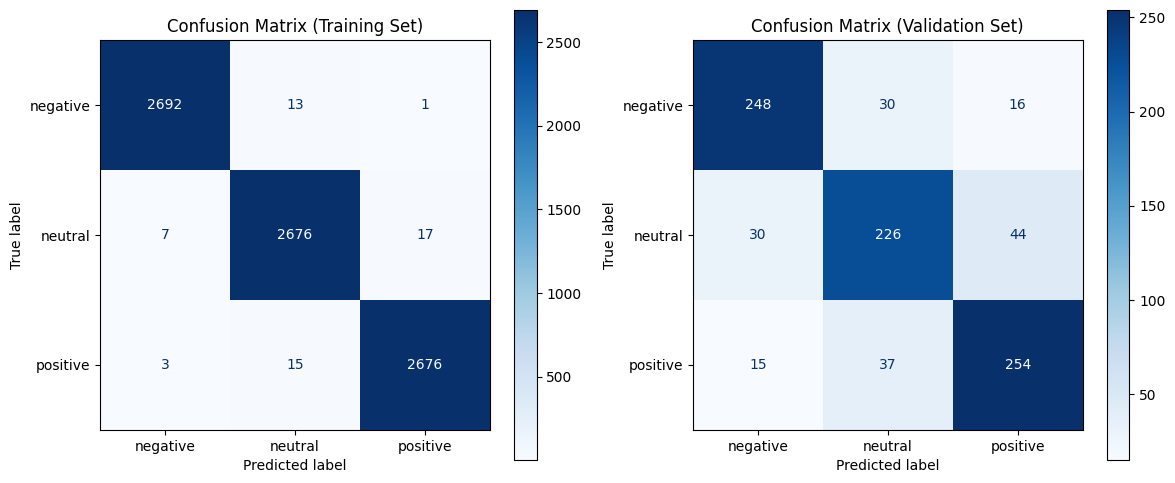

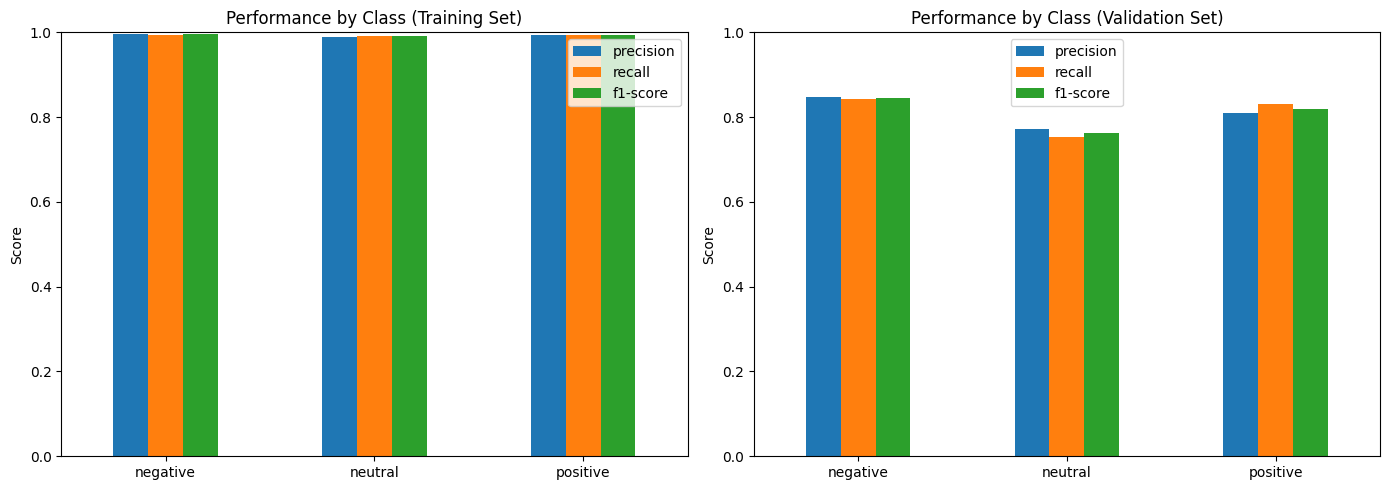

In [31]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

y_train_pred = pipeline.predict(text_train)
y_test_pred = pipeline.predict(text_test)

print("Training Set Performance :")
print("Accuracy:", accuracy_score(sentiment_train, y_train_pred))
print(classification_report(sentiment_train, y_train_pred))
print()
print("Validation Set Performance :")
print("Accuracy:", accuracy_score(sentiment_test, y_test_pred))
print(classification_report(sentiment_test, y_test_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    sentiment_train,
    y_train_pred,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Training Set)")

ConfusionMatrixDisplay.from_predictions(
    sentiment_test,
    y_test_pred,
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix (Validation Set)")

plt.tight_layout()
plt.show()

report_train = classification_report(sentiment_train, y_train_pred, output_dict=True)
report_test = classification_report(sentiment_test, y_test_pred, output_dict=True)

df_train = pd.DataFrame(report_train).transpose().iloc[:3]
df_test = pd.DataFrame(report_test).transpose().iloc[:3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train[["precision", "recall", "f1-score"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Performance by Class (Training Set)")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 1)

df_test[["precision", "recall", "f1-score"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Performance by Class (Validation Set)")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()